<center><h1>Xie_Chong_HW5</h1></center>
<br>
<br>

Name: Chong Xie
<br>
Github Username: cxieusc
<br>
USC ID: 6800668300

## 1. Decision Trees as Interpretable Models

Import packages

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import itertools
import statsmodels.api as sm
import os
from sklearn.tree import DecisionTreeClassifier,plot_tree,_tree
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

### (a) Obtain Data

Import the Accute Inamations Data Set

In [17]:
diagnosis_columns = [
    "temperature",
    "nausea",
    "lumbar-pain",
    "urine-pushing",
    "micturition-pains",
    "burning-urethra",
    "bladder-inflammation",
    "nephritis",
]

df = pd.read_csv(
    "../data/diagnosis.data",
    sep="\t",
    encoding="utf-16",
    decimal=",",
    header=None,
    names=diagnosis_columns,
)

df.head(5)

,temperature,nausea,lumbar-pain,urine-pushing,micturition-pains,burning-urethra,bladder-inflammation,nephritis
0,35.5,no,yes,no,no,no,no,no
1,35.9,no,no,yes,yes,yes,yes,no
2,35.9,no,yes,no,no,no,no,no
3,36.0,no,no,yes,yes,yes,yes,no
4,36.0,no,yes,no,no,no,no,no


### (b) Build a decision tree

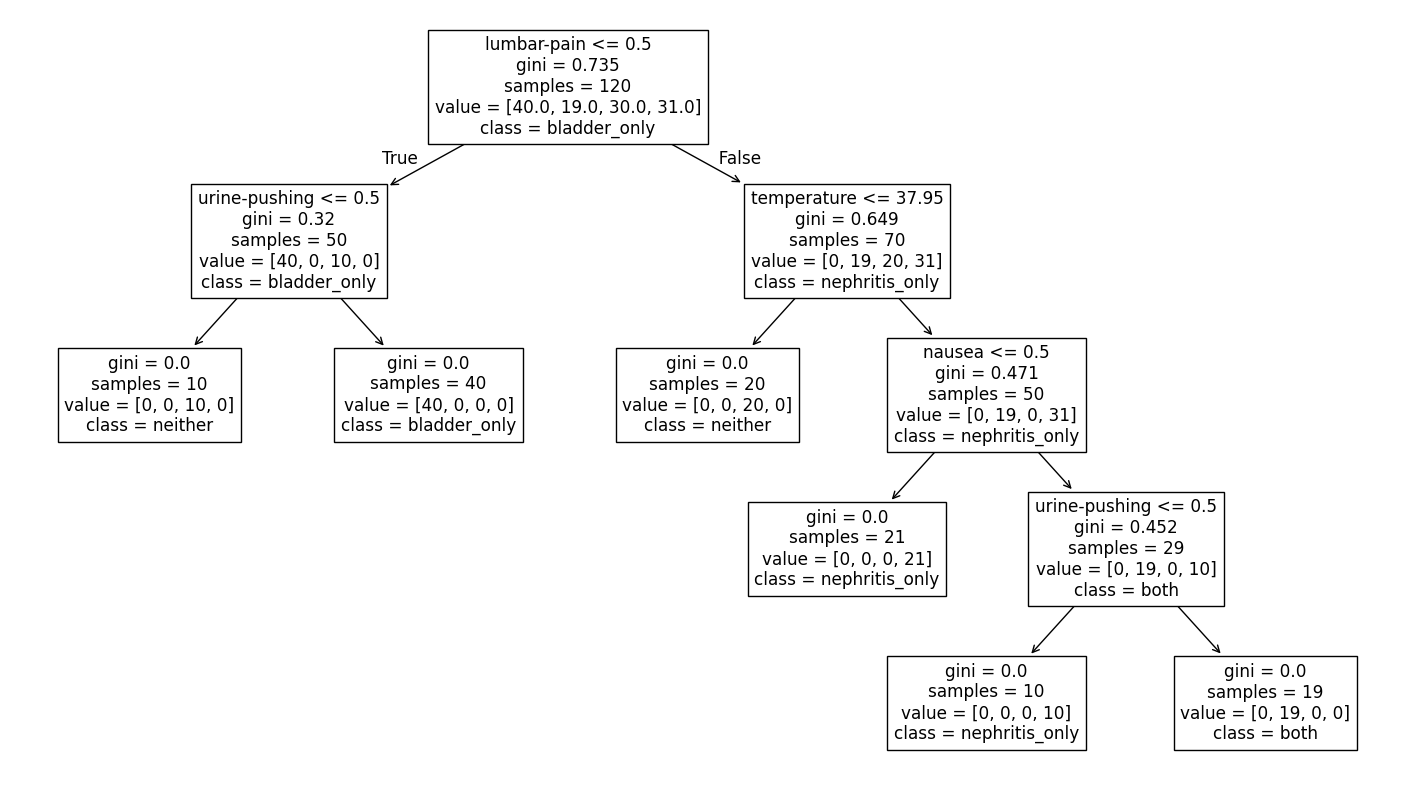

In [18]:
features = diagnosis_columns[:-2]
targets = diagnosis_columns[-2:]
X = df[features].copy()

for col in X.columns[1:]:
    X[col] = X[col].map({"no": 0, "yes": 1})

label_map = {
    ("no", "no"): "neither",
    ("yes", "no"): "bladder_only",
    ("no", "yes"): "nephritis_only",
    ("yes", "yes"): "both",
}

y = df[targets].apply(
    lambda row: label_map[tuple(row)],
    axis=1,
)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X, y)

plt.figure(figsize=(18, 10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=dt.classes_,
)
plt.show()

### (c) Convert the decision rules

This code was taken from https://www.kdnuggets.com/2017/05/simplifying-decision-tree-interpretation-decision-rules-python.html as said in the homework PDF

In [23]:
def tree_to_pseudo(tree, feature_names):
	"""
	Outputs a decision tree model as if/then pseudocode
	
	Parameters:
	-----------
	tree: decision tree model
		The decision tree to represent as pseudocode
	feature_names: list
		The feature names of the dataset used for building the decision tree
	"""

	left = tree.tree_.children_left
	right = tree.tree_.children_right
	threshold = tree.tree_.threshold
	features = [feature_names[i] for i in tree.tree_.feature]
	value = tree.tree_.value

	def recurse(left, right, threshold, features, node, depth=0):
		indent = "  " * depth
		if (threshold[node] != -2):
			print(indent,"if ( " + features[node] + " <= " + str(threshold[node]) + " ) {")
			if left[node] != -1:
				recurse (left, right, threshold, features, left[node], depth+1)
				print(indent,"} else {")
				if right[node] != -1:
					recurse (left, right, threshold, features, right[node], depth+1)
				print(indent,"}")
		else:
			print(indent,"return " + str(value[node]))

	recurse(left, right, threshold, features, 0)

In [24]:
tree_to_pseudo(dt, X.columns)

 if ( lumbar-pain <= 0.5 ) {
   if ( urine-pushing <= 0.5 ) {
     return [[0. 0. 1. 0.]]
   } else {
     return [[1. 0. 0. 0.]]
   }
 } else {
   if ( temperature <= 37.95000076293945 ) {
     return [[0. 0. 1. 0.]]
   } else {
     if ( nausea <= 0.5 ) {
       return [[0. 0. 0. 1.]]
     } else {
       if ( urine-pushing <= 0.5 ) {
         return [[0. 0. 0. 1.]]
       } else {
         return [[0. 1. 0. 0.]]
       }
     }
   }
 }


### (d) Cost-Complexity Pruning

In [25]:
path = dt.cost_complexity_pruning_path(X, y)

results = []

for alpha in path.ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha,
    )
    model.fit(X, y)

    results.append({
        "ccp_alpha": alpha,
        "depth": model.get_depth(),
        "leaves": model.get_n_leaves(),
        "training_accuracy": model.score(X, y),
    })

pruning_results = pd.DataFrame(results)
pruning_results

,ccp_alpha,depth,leaves,training_accuracy
0,0.000000,4,6,1.000000
1,0.098167,2,4,0.841667
2,0.133333,2,3,0.758333
3,0.182000,1,2,0.591667
4,0.222917,0,1,0.333333


In [26]:
eligible = pruning_results[
    pruning_results["training_accuracy"] >= 0.80
]

selected = eligible.sort_values(
    ["leaves", "ccp_alpha"]
).iloc[0]

selected_alpha = float(selected["ccp_alpha"])

pruned_dt = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=selected_alpha,
)
pruned_dt.fit(X, y)

print("Selected alpha:", selected_alpha)
print("Tree depth:", pruned_dt.get_depth())
print("Number of leaves:", pruned_dt.get_n_leaves())
print("Training accuracy:", pruned_dt.score(X, y))

Selected alpha: 0.09816666666666667
Tree depth: 2
Number of leaves: 4
Training accuracy: 0.8416666666666667


I used cost-complexity pruning to generate a sequence of simpler trees. Among the candidate trees with training accuracy of at least 80%, I selected the tree with the fewest leaves. The selected alpha is approximately 0.098167. Pruning reduces the depth from 4 to 2 and the number of leaves from 6 to 4, while training accuracy decreases from 100% to 84.17%. The resulting rules are shorter and easier to interpret, at the cost of classification accuracy.

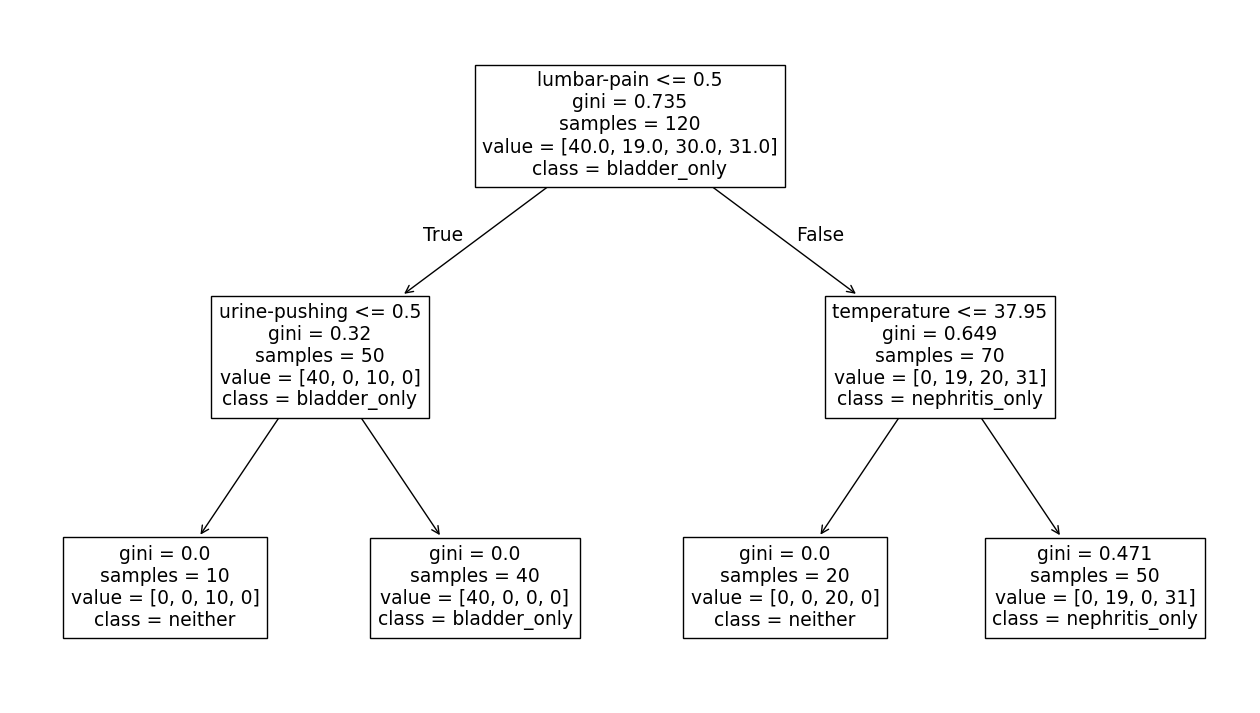

In [30]:
plt.figure(figsize=(16, 9))
plot_tree(
    pruned_dt,
    feature_names=X.columns,
    class_names=pruned_dt.classes_,
)
plt.show()

In [32]:
tree_to_pseudo(pruned_dt, X.columns)

 if ( lumbar-pain <= 0.5 ) {
   if ( urine-pushing <= 0.5 ) {
     return [[0. 0. 1. 0.]]
   } else {
     return [[1. 0. 0. 0.]]
   }
 } else {
   if ( temperature <= 37.95000076293945 ) {
     return [[0. 0. 1. 0.]]
   } else {
     return [[0.   0.38 0.   0.62]]
   }
 }


## 2. The LASSO and Boosting for Regression

### (a) Obtain Data

### (b) Missing values

### (c) Plot a correlation matrix

### (d) Calculate the Coefficient of Variation CV

### (e) Scatter plots and box plots for highest CV features

### (f) Fit a linear model

### (g) Fit a ridge regression model

### (h) Fit a LASSO model

### (i) Fit a PCR model

### (j) Fit a boosting tree